In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import gsw
from sklearn.mixture import GaussianMixture
from funcs import cross_sec_lon, cross_sec_lon_prob, cross_sec_lon_prob2, calc_pv, method34

In [3]:
# Get data into dataframe
df = pd.read_csv('../../WMA_fractions_v2_with_PV.csv')

# Preprocess data to contain the relevant features
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]','Profile_Number', 'PV', 'dPVdz']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month','Profile_Number', 'PV', 'dPVdz']]

In [4]:
# Define random master seed for reproducibility
master_seed = 22
random.seed(master_seed)

# Ensemble size
ensemble_size = 5

# Define a list of random seeds
seeds = random.sample(range(1, 10000), ensemble_size)

In [5]:
# Define features to use for clustering
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'dPVdz']

In [6]:
df_sampled = method34(df=df_ST, seed=master_seed)

In [7]:
# Do BIC and AIC calculation for different number of clusters and for 10 different seeds
all_scores = {}
all_aic_scores = {}
n_components_range = range(1, 8)
for i,seed in enumerate(seeds):
    bic_scores = [] 
    aic_scores = []
    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
        gmm.fit(df_sampled[features])
        bic_scores.append(gmm.bic(df_sampled[features]))
        aic_scores.append(gmm.aic(df_sampled[features]))

    all_scores[i] = bic_scores
    all_aic_scores[i] = aic_scores

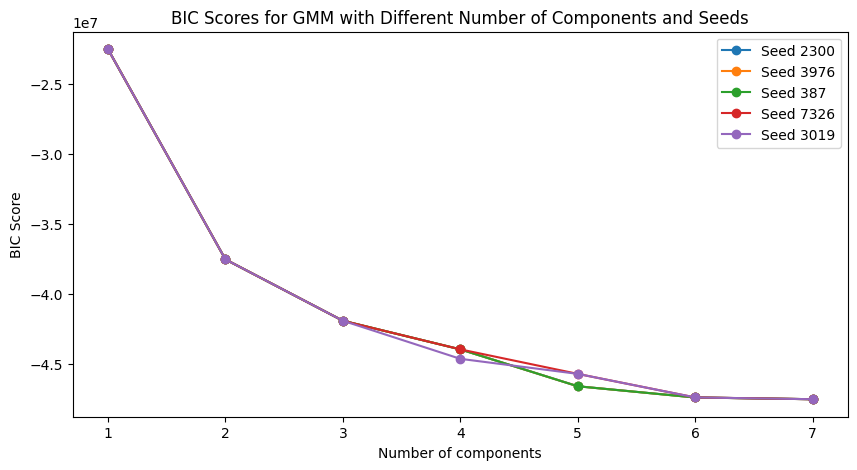

In [8]:
plt.figure(figsize=(10,5))
for i in range(ensemble_size):
    plt.plot(n_components_range, all_scores[i], label=f'Seed {seeds[i]}', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components and Seeds')
plt.legend()

In [9]:
# Choice of optimal number of clusters based on BIC
n_clusters = 6

In [10]:
gmms = []
labels = [] 
for i,seed in enumerate(seeds):
    gmm = GaussianMixture(
        n_components=n_clusters,          # number of clusters
        covariance_type='full',  # full cov matrix has more flexibility
        random_state=seed)
    gmm.fit(df_sampled[features])
    gmms.append(gmm)
    labels.append(gmm.predict(df_sampled[features]))

In [11]:
# Preprocess for comparison of cluster labels across ensemble members,
# following Poropat et al. (2024), Sect. 2.3.
#
# Classes are matched on the CORRELATION between their D-dimensional mean
# vectors (mean T, S, depth), NOT on Euclidean distance. A cluster only
# matches an existing class if the correlation exceeds a minimal threshold
# (0.98 in the paper); otherwise it becomes a NEW reference class. This yields
# a list of reference classes that is usually longer than the per-model K,
# because some classes appear in only a few ensemble members.

MIN_CORRELATION = 0.98   # minimal correlation for matching classes (Poropat et al., 2024)

# Full D-dimensional mean vector (mean T, S, depth) of every cluster.
cluster_means = [gmms[i].means_ for i in range(ensemble_size)]

# NOTE: correlation centres each mean vector by its own across-dimension mean,
# so dimensions with very different units (T ~ °C, S ~ PSU, depth ~ m) are not
# comparable on raw values and depth would dominate. Standardise each dimension
# across all clusters first so the correlation reflects relative position in
# each variable. (In the paper the means live in EOF space, already comparable.)
all_means = np.vstack(cluster_means)
feat_mean = all_means.mean(axis=0)
feat_std  = all_means.std(axis=0)
feat_std[feat_std == 0] = 1.0
cluster_means = [(m - feat_mean) / feat_std for m in cluster_means]

def _corr(a, b):
    """Pearson correlation between two mean vectors (needs >= 3 dimensions)."""
    return np.corrcoef(np.asarray(a, float), np.asarray(b, float))[0, 1]

reference_means = []   # mean vector defining each reference class
matched_labels  = []   # per member: reference-class id of each local cluster

for i in range(ensemble_size):
    means = cluster_means[i]
    matched = np.empty(means.shape[0], dtype=int)
    for j in range(means.shape[0]):
        best_corr, best_ref = -np.inf, -1
        for r, ref in enumerate(reference_means):
            c = _corr(means[j], ref)
            if c > best_corr:
                best_corr, best_ref = c, r
        if best_ref != -1 and best_corr >= MIN_CORRELATION:
            matched[j] = best_ref                       # matches an existing class
        else:
            reference_means.append(means[j])            # no match -> new class
            matched[j] = len(reference_means) - 1
    matched_labels.append(matched)

n_reference_classes = len(reference_means)
print(f"{n_reference_classes} reference classes found across {ensemble_size} members "
      f"(K = {n_clusters} per model)")


5 reference classes found across 5 members (K = 6 per model)


In [13]:
matched

array([3, 0, 2, 4, 1, 0])